## TRAINING PHASE

Training phase (we use NTU RGB+D for training our Support Vector Machine model because it has action recognition (walking, eating))

In [30]:
pip install numpy==1.24.4 pandas scikit-learn opencv-python matplotlib seaborn jupyter tqdm mediapipe

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.4.7-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.16.6-py3-none-any.whl.metadata (8.5 kB)
  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.3.8-py3-none-any.whl.metadata (16 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.0.4-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_lsp-2.3.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.14.2-py3-none-any.whl.metadata (8.4 kB)
  Using cached jupyterlab_server-2.27.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached tomli-2.3.0-py3-

  error: subprocess-exited-with-error
  
  × pip subprocess to install backend dependencies did not run successfully.
  │ exit code: 1
  ╰─> [2 lines of output]
      ERROR: Could not find a version that satisfies the requirement puccinialin (from versions: none)
      ERROR: No matching distribution found for puccinialin
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
error: subprocess-exited-with-error

× pip subprocess to install backend dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


### Data loading and processing


In [98]:
import numpy as np
import os

class NTUNpyLoader:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.joint_count = 25
        self.person_count = 2
        self.coord_dim = 3
        self.max_frames = 300

    def load_npy_dataset(self):
        """Load the .npy files """
        x_train_path = os.path.join(self.dataset_path, 'x_train.npy')
        y_train_path = os.path.join(self.dataset_path, 'y_train.npy')
        x_test_path = os.path.join(self.dataset_path, 'x_test.npy')
        y_test_path = os.path.join(self.dataset_path, 'y_test.npy')

        # Check if files exist
        for path in [x_train_path, y_train_path, x_test_path, y_test_path]:
            if not os.path.exists(path):
                raise FileNotFoundError(f"File not found: {path}")

        print("Loading .npy files...")

        # SIMPLE DIRECT LOADING 
        x_train = np.load(x_train_path)
        y_train = np.load(y_train_path)
        x_test = np.load(x_test_path)
        y_test = np.load(y_test_path)

        print(f"Training data: {x_train.shape}, labels: {y_train.shape}")
        print(f"Testing data: {x_test.shape}, labels: {y_test.shape}")

        # Check if labels are one-hot and convert if needed
        if len(y_train.shape) > 1 and y_train.shape[1] > 1:
            print("Converting one-hot labels to class indices...")
            y_train = np.argmax(y_train, axis=1)
            y_test = np.argmax(y_test, axis=1)

        return (x_train, y_train), (x_test, y_test)

    def reshape_skeleton_sequence(self, sequence):
        """
        Reshape sequence from (300, 150) to (300, 2, 25, 3)
        150 = 2 persons × 25 joints × 3 coordinates
        """
        reshaped = sequence.reshape(self.max_frames, self.person_count, self.joint_count, self.coord_dim)
        return reshaped

    def get_valid_frames(self, sequence):
        """
        Extract valid (non-zero padded) frames from sequence
        """
        # Find frames where there's actual data (not all zeros)
        frame_has_data = np.any(sequence != 0, axis=1)  # Check along feature dimension
        valid_indices = np.where(frame_has_data)[0]

        if len(valid_indices) == 0:
            return sequence[:1]  # Return at least one frame

        return sequence[valid_indices]

    def get_action_names(self):
        """NTU RGB+D 60 action classes"""
        action_names = [
            "drink water", "eat meal", "brush teeth", "brush hair", "drop", "pick up",
            "throw", "sitting down", "standing up", "clapping", "reading", "writing",
            "tear up paper", "wear jacket", "take off jacket", "wear a shoe", "take off a shoe",
            "wear on glasses", "take off glasses", "put on a hat", "take off a hat",
            "cheer up", "hand waving", "kicking something", "reach into pocket",
            "hopping", "jump up", "make a phone call", "playing with phone", "type on a keyboard",
            "point to something", "taking a selfie", "check time (from watch)", "rub two hands",
            "nod head", "shake head", "wipe face", "salute", "put palms together",
            "cross hands in front", "sneeze", "staggering", "falling down", "touch head",
            "touch chest", "touch back", "touch neck", "nausea or vomiting", "use a fan",
            "punching", "kicking", "pushing", "pat on back", "point finger", "hugging",
            "giving something", "touch pocket", "shooting", "walking towards", "walking apart"
        ]
        return action_names

### Feature extraction


In [ ]:
from scipy.spatial import distance

class NTUProcessedFeatureExtractor:
    def __init__(self):
        # NTU RGB+D 25 Joints
        self.joint_names = [
            "pelvis",       # 1(base of spine)
            "middle_of_spine",      # 2 
            "neck", "head", # 3, 4
            "left_shoulder", "left_elbow", "left_wrist",  # 5, 6, 7
            "left_hand", "right_shoulder", # 8, 9 
            "right_elbow", "right_wrist",  # 10, 11
            "right_hand", "left_hip", # 12, 13
            "left_knee", "left_ankle", "left_foot",  # 14, 15, 16
            "right_hip", "right_knee", "right_ankle", "right_foot",  # 17, 18, 19, 20
            "spine", "tip_left_hand" # 21, 22
            "left_thumb", "tip_right_hand" #23, 24
            "right_thumb" #25
        ]
        
        # Bone Pairs for NTU RGB+D (consistent with joint indices)
        self.bone_pairs = [
            # Spine chain
            (0, 1),    # pelvis → middle_of_spine
            (1, 20),   # middle_of_spine → spine  
            (20, 2),   # spine → neck
            (2, 3),    # neck → head
            
            # Left arm chain
            (2, 4),    # neck → left_shoulder
            (4, 5),    # left_shoulder → left_elbow
            (5, 6),    # left_elbow → left_wrist
            (6, 7),    # left_wrist → left_hand
            (6, 21),   # left_wrist → tip_left_hand
            (6, 22),   # left_wrist → left_thumb
            
            # Right arm chain
            (2, 8),    # neck → right_shoulder
            (8, 9),    # right_shoulder → right_elbow
            (9, 10),   # right_elbow → right_wrist
            (10, 11),  # right_wrist → right_hand
            (10, 23),  # right_wrist → tip_right_hand
            (10, 24),  # right_wrist → right_thumb
            
            # Left leg chain
            (0, 12),   # pelvis → left_hip
            (12, 13),  # left_hip → left_knee
            (13, 14),  # left_knee → left_ankle
            (14, 15),  # left_ankle → left_foot
            
            # Right leg chain
            (0, 16),   # pelvis → right_hip  
            (16, 17),  # right_hip → right_knee
            (17, 18),  # right_knee → right_ankle
            (18, 19),  # right_ankle → right_foot
        ]

        # Action-specific joint groups
        self.hand_joints = [7, 21, 22, 11, 23, 24]  # All hand-related joints
        self.arm_joints = [4, 5, 6, 8, 9, 10]       # Shoulders, elbows, wrists
        self.leg_joints = [12, 13, 14, 15, 16, 17, 18, 19]  # All leg joints

        # NEW: Track feature extraction statistics
        self.extraction_stats = {
            'total_sequences': 0,
            'successful_extractions': 0,
            'failed_min_frames': 0,
            'failed_empty_features': 0
        }


    def extract_features_from_sequence(self, sequence):
        """
        Extract features from preprocessed NTU sequence
        IMPROVED: More robust feature extraction to preserve class balance
        """
        self.extraction_stats['total_sequences'] += 1
        
        # Reshape sequence
        reshaped_sequence = sequence.reshape(300, 2, 25, 3)

        # Use only the first person (main subject)
        main_person_sequence = reshaped_sequence[:, 0, :, :]  # (300, 25, 3)

        # Remove zero-padded frames
        valid_frames = self.get_valid_frames(main_person_sequence)

        # REDUCED minimum frames requirement to preserve samples
        if len(valid_frames) < 5:  # Reduced from 10 to 5
            self.extraction_stats['failed_min_frames'] += 1
            # Instead of returning empty, try to extract basic features
            return self.extract_minimal_features(valid_frames)

        features = []

        # 1. SPATIAL FEATURES - Use multiple frames for robustness
        spatial_features = self.extract_robust_spatial_features(valid_frames)
        features.extend(spatial_features)

        # 2. TEMPORAL FEATURES - Handle edge cases better
        temporal_features = self.extract_robust_temporal_features(valid_frames)
        features.extend(temporal_features)

        # 3. STATISTICAL FEATURES - More tolerant to short sequences
        statistical_features = self.extract_robust_statistical_features(valid_frames)
        features.extend(statistical_features)

        # 4. ACTION-SPECIFIC FEATURES - Handle partial data
        action_features = self.extract_robust_action_features(valid_frames)
        features.extend(action_features)

        features_array = np.array(features)
        
        # Check if we have meaningful features
        if len(features_array) == 0 or np.all(features_array == 0):
            self.extraction_stats['failed_empty_features'] += 1
            return self.extract_minimal_features(valid_frames)  # Fallback to minimal features
            
        self.extraction_stats['successful_extractions'] += 1
        return features_array

    def extract_minimal_features(self, valid_frames):
        """Extract minimal features even with limited data to preserve samples"""
        features = []
        
        if len(valid_frames) == 0:
            # Return zero features but don't discard the sample entirely
            return np.zeros(100)  # Fixed size for consistency
            
        # Use whatever frames we have
        for i in range(min(3, len(valid_frames))):  # Use up to 3 frames
            frame = valid_frames[i]
            # Basic joint positions
            features.extend(frame.flatten())
            
            # Basic bone lengths (first 5 bone pairs only)
            for j1, j2 in self.bone_pairs[:5]:
                if (j1 < len(frame) and j2 < len(frame)):
                    bone_vector = frame[j2] - frame[j1]
                    features.extend(bone_vector[:2])  # Only x,y for minimal features
                    features.append(np.linalg.norm(bone_vector))
        
        # Pad to fixed length for consistency
        if len(features) < 100:
            features.extend([0.0] * (100 - len(features)))
        else:
            features = features[:100]
            
        return np.array(features)

    def extract_robust_spatial_features(self, valid_frames):
        """More robust spatial feature extraction using multiple frames"""
        features = []
        
        # Use start, middle, and end frames for spatial diversity
        frame_indices = [0, len(valid_frames)//2, -1]
        used_frames = 0
        
        for idx in frame_indices:
            if idx < len(valid_frames):
                frame_features = self.extract_spatial_features(valid_frames[idx])
                features.extend(frame_features)
                used_frames += 1
        
        # If we couldn't get features from multiple frames, duplicate the ones we have
        if used_frames == 1 and len(features) > 0:
            features.extend(features)  # Duplicate to increase feature weight
            
        return features

    def extract_robust_temporal_features(self, valid_frames):
        """Temporal features that work with shorter sequences"""
        features = []
        
        if len(valid_frames) < 2:
            # Return placeholder temporal features
            return [0.0] * 10
            
        try:
            # 1. Joint velocities (motion patterns)
            velocities = np.diff(valid_frames, axis=0)
            
            # Mean velocity per joint type - handle empty cases
            velocity_features = []
            for joint_group, group_name in [(self.hand_joints, 'hand'), 
                                          (self.arm_joints, 'arm'), 
                                          (self.leg_joints, 'leg')]:
                if len(velocities) > 0:
                    group_velocities = velocities[:, joint_group, :]
                    if len(group_velocities) > 0:
                        motion = np.mean(np.linalg.norm(group_velocities, axis=2))
                        velocity_features.append(motion)
                    else:
                        velocity_features.append(0.0)
                else:
                    velocity_features.append(0.0)
            
            features.extend(velocity_features)

            # 2. Basic motion statistics
            if len(valid_frames) > 3:
                try:
                    acceleration = np.diff(velocities, axis=0)
                    if len(acceleration) > 0:
                        motion_smoothness = np.mean(np.linalg.norm(acceleration, axis=2))
                        features.append(motion_smoothness)
                    else:
                        features.append(0.0)
                except:
                    features.append(0.0)
            else:
                features.append(0.0)

            # 3. Simple periodicity measure
            periodicity = self.calculate_simple_periodicity(valid_frames)
            features.extend(periodicity)

        except Exception as e:
            # If temporal features fail, use placeholders
            features.extend([0.0] * (10 - len(features)))
            
        return features

    def calculate_simple_periodicity(self, valid_frames):
        """Simplified periodicity calculation that works with shorter sequences"""
        if len(valid_frames) < 3:
            return [0.0, 0.0]
            
        try:
            # Use torso motion for periodicity (more reliable than hands)
            torso_joints = [0, 1, 2, 20]  # Pelvis, middle spine, neck, spine
            torso_positions = valid_frames[:, torso_joints, :]
            torso_motion = np.linalg.norm(torso_positions, axis=2).mean(axis=1)
            
            if len(torso_motion) > 1:
                # Simple variance-based periodicity
                motion_variance = np.var(torso_motion)
                # Basic autocorrelation at lag 1
                if len(torso_motion) > 2:
                    autocorr = np.corrcoef(torso_motion[:-1], torso_motion[1:])[0,1]
                    if np.isnan(autocorr):
                        autocorr = 0.0
                else:
                    autocorr = 0.0
            else:
                motion_variance = 0.0
                autocorr = 0.0
                
            return [autocorr, motion_variance]
        except:
            return [0.0, 0.0]

    def extract_robust_statistical_features(self, valid_frames):  
        """Statistical features that work with any sequence length"""
        features = []

        if len(valid_frames) == 0:
            return [0.0] * 30

        try:
            # 1. Basic statistics for major joints only (reduce dimensionality)
            major_joints = [0, 2, 4, 5, 6, 8, 9, 10, 12, 13, 16, 17]  # Key joints only
            
            for joint_idx in major_joints:
                if joint_idx < valid_frames.shape[1]:
                    joint_data = valid_frames[:, joint_idx, :]
                    
                    if np.any(joint_data != 0):
                        # Mean position
                        features.extend(np.mean(joint_data, axis=0))
                        # Standard deviation (movement variability)
                        features.extend(np.std(joint_data, axis=0))
                    else:
                        features.extend([0.0] * 6)

            # 2. Global motion statistics (simplified)
            if len(valid_frames) > 1:
                try:
                    # Center of mass using major joints only
                    major_joint_data = valid_frames[:, major_joints, :]
                    frame_centers = np.mean(major_joint_data, axis=1)
                    center_movement = np.diff(frame_centers, axis=0)
                    
                    if len(center_movement) > 0:
                        movement_magnitudes = np.linalg.norm(center_movement, axis=1)
                        features.append(np.mean(movement_magnitudes))
                    else:
                        features.append(0.0)
                except:
                    features.append(0.0)
            else:
                features.append(0.0)

        except Exception as e:
            # If statistical features fail, use placeholders
            features.extend([0.0] * (30 - len(features)))
            
        return features

    def extract_robust_action_features(self, valid_frames):
        """Action-specific features that handle edge cases"""
        features = []
        
        try:
            # 1. Hand-specific features (simplified)
            hand_features = self.extract_simple_hand_features(valid_frames)
            features.extend(hand_features)
            
            # 2. Upper body vs lower body motion ratio
            motion_ratio_features = self.extract_simple_motion_ratios(valid_frames)
            features.extend(motion_ratio_features)
            
            # 3. Basic symmetry features
            symmetry_features = self.extract_simple_symmetry(valid_frames)
            features.extend(symmetry_features)
            
        except:
            # If action features fail, use placeholders
            features.extend([0.0] * (15 - len(features)))
            
        return features

    def extract_simple_hand_features(self, valid_frames):
        """Simplified hand features"""
        if len(valid_frames) < 2:
            return [0.0] * 3
            
        features = []
        
        try:
            # Basic hand distance (first and last frame only)
            first_frame = valid_frames[0]
            last_frame = valid_frames[-1]
            
            hand_distances = []
            for frame in [first_frame, last_frame]:
                if (len(frame) > 11 and np.any(frame[7] != 0) and np.any(frame[11] != 0)):
                    distance = np.linalg.norm(frame[7] - frame[11])
                    hand_distances.append(distance)
            
            if hand_distances:
                features.append(np.mean(hand_distances))
                features.append(np.min(hand_distances))
            else:
                features.extend([0.0, 0.0])
                
            # Simple hand motion
            if len(valid_frames) > 1:
                hand_positions = valid_frames[:, [7, 11], :]  # Just left and right hands
                hand_motion = np.mean(np.linalg.norm(np.diff(hand_positions, axis=0), axis=2))
                features.append(hand_motion)
            else:
                features.append(0.0)
                
        except:
            features.extend([0.0] * (3 - len(features)))
            
        return features

    def extract_simple_motion_ratios(self, valid_frames):
        """Simplified motion ratio calculation"""
        if len(valid_frames) < 2:
            return [0.0, 0.0]
            
        try:
            upper_body_joints = [2, 4, 5, 6, 8, 9, 10]  # Reduced set
            lower_body_joints = [0, 12, 13, 16, 17]     # Reduced set
            
            velocities = np.diff(valid_frames, axis=0)
            
            if len(velocities) > 0:
                upper_velocities = velocities[:, upper_body_joints, :]
                lower_velocities = velocities[:, lower_body_joints, :]
                
                upper_motion = np.mean(np.linalg.norm(upper_velocities, axis=2))
                lower_motion = np.mean(np.linalg.norm(lower_velocities, axis=2))
                
                if lower_motion > 0.001:
                    motion_ratio = upper_motion / lower_motion
                else:
                    motion_ratio = upper_motion * 10  # Reduced multiplier
            else:
                upper_motion = 0.0
                lower_motion = 0.0
                motion_ratio = 0.0
                
            return [motion_ratio, upper_motion]
        except:
            return [0.0, 0.0]

    def extract_simple_symmetry(self, valid_frames):
        """Simplified symmetry calculation"""
        if len(valid_frames) < 2:
            return [0.0, 0.0]
            
        try:
            left_joints = [4, 5, 6, 12, 13]   # Reduced set
            right_joints = [8, 9, 10, 16, 17] # Reduced set
            
            # Use position symmetry instead of motion symmetry
            left_positions = valid_frames[:, left_joints, :].mean(axis=1)
            right_positions = valid_frames[:, right_joints, :].mean(axis=1)
            
            position_differences = np.linalg.norm(left_positions - right_positions, axis=1)
            symmetry_score = 1.0 - np.mean(position_differences) / 2.0  # Rough normalization
            symmetry_score = np.clip(symmetry_score, 0.0, 1.0)
            
            return [symmetry_score, np.mean(position_differences)]
        except:
            return [0.0, 0.0]

    def get_extraction_stats(self):
        """Get statistics about feature extraction success rates"""
        stats = self.extraction_stats.copy()
        if stats['total_sequences'] > 0:
            stats['success_rate'] = stats['successful_extractions'] / stats['total_sequences']
        else:
            stats['success_rate'] = 0.0
        return stats

    def reset_stats(self):
        """Reset extraction statistics"""
        self.extraction_stats = {
            'total_sequences': 0,
            'successful_extractions': 0,
            'failed_min_frames': 0,
            'failed_empty_features': 0
        }

    def get_valid_frames(self, sequence):
        """Extract non-zero padded frames efficiently"""
        # Check if frames have meaningful data (not all zeros)
        frame_has_data = np.any(sequence != 0, axis=(1, 2))
        valid_indices = np.where(frame_has_data)[0]
        
        if len(valid_indices) == 0:
            return sequence[:5]  # Return minimal frames
        
        return sequence[valid_indices]
    
    def extract_spatial_features(self, skeleton_frame):
        """Your original spatial feature extraction"""
        features = []
  
        features.extend(skeleton_frame.flatten())

        for j1, j2 in self.bone_pairs:
            if (j1 < len(skeleton_frame) and j2 < len(skeleton_frame) and
                np.any(skeleton_frame[j1] != 0) and np.any(skeleton_frame[j2] != 0)):
                
                bone_vector = skeleton_frame[j2] - skeleton_frame[j1]
                features.extend(bone_vector)
                
                bone_length = np.linalg.norm(bone_vector)
                spine_length = np.linalg.norm(skeleton_frame[2] - skeleton_frame[1])
                if spine_length > 0.1:
                    features.append(bone_length / spine_length)
                else:
                    features.append(bone_length)
            else:
                features.extend([0, 0, 0, 0])

        key_joints = [3, 7, 11, 15, 19]  
        spine_base = skeleton_frame[0]
        for joint_idx in key_joints:
            if (joint_idx < len(skeleton_frame) and 
                np.any(skeleton_frame[joint_idx] != 0) and 
                np.any(spine_base != 0)):
                
                distance_vec = skeleton_frame[joint_idx] - spine_base
                features.extend(distance_vec)
                features.append(np.linalg.norm(distance_vec))
            else:
                features.extend([0, 0, 0, 0])

        angles = self.calculate_joint_angles(skeleton_frame)  
        features.extend(angles)

        return np.array(features)
    
    def calculate_joint_angles(self, skeleton):
        """Your original joint angle calculation"""
        angles = []
    
        if (len(skeleton) > 6 and 
            np.any(skeleton[4] != 0) and np.any(skeleton[5] != 0) and np.any(skeleton[6] != 0)):
            left_shoulder = skeleton[4]    
            left_elbow = skeleton[5]        
            left_wrist = skeleton[6]       
            angle = self.calculate_angle(left_shoulder, left_elbow, left_wrist)
            angles.append(angle)
        else:
            angles.append(0.0)

        return angles

    def calculate_angle(self, point1, point2, point3):
        """Your original angle calculation"""
        vec1 = point1 - point2
        vec2 = point3 - point2

        if (np.linalg.norm(vec1) > 0.001 and np.linalg.norm(vec2) > 0.001 and
            np.any(vec1 != 0) and np.any(vec2 != 0)):
            
            cosine_angle = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
            cosine_angle = np.clip(cosine_angle, -1, 1)
            return np.arccos(cosine_angle)
        return 0.0

### Main function for training

In [100]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import pickle
from tqdm import tqdm

class NTUNpyTrainer:
    def __init__(self, dataset_path, use_random_forest=False):  # Add parameter
        self.dataset_path = dataset_path
        self.data_loader = NTUNpyLoader(dataset_path)
        self.feature_extractor = NTUProcessedFeatureExtractor()
        self.scaler = StandardScaler()
        self.use_random_forest = use_random_forest  
        
        
    def prepare_features(self, x_data, y_data, max_samples=None):
        """Extract features from raw sequences"""
        if max_samples and max_samples < len(x_data):
            x_data = x_data[:max_samples]
            y_data = y_data[:max_samples]
        
        print("Extracting features...")
        X_features = []
        y_filtered = []
        
        for i in tqdm(range(len(x_data))):
            try:
                features = self.feature_extractor.extract_features_from_sequence(x_data[i])
                if len(features) > 50:  # Ensure we have meaningful features
                    X_features.append(features)
                    y_filtered.append(y_data[i])
            except Exception as e:
                if i % 500 == 0:  # Print occasional errors
                    print(f"Error processing sample {i}: {e}")
                continue
        
        print(f"Successfully processed {len(X_features)}/{len(x_data)} samples")
        
        # Handle variable length features by padding
        X_padded = self.pad_features(X_features)
        
        return X_padded, np.array(y_filtered)
    
    def pad_features(self, features_list):
        """Pad feature vectors to same length"""
        if len(features_list) == 0:
            return np.array([])
            
        # Find maximum length
        lengths = [len(x) for x in features_list]
        max_len = max(lengths)
        min_len = min(lengths)
        
        print(f"Feature lengths - Min: {min_len}, Max: {max_len}")
        
        # Pad sequences
        X_padded = np.zeros((len(features_list), max_len))
        for i, seq in enumerate(features_list):
            X_padded[i, :len(seq)] = seq
        
        return X_padded
    
    def train_model(self, X_train, y_train, X_test, y_test):
        """Train either SVM or Random Forest based on flag"""
        print("Scaling features...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        if self.use_random_forest:
            print("Training Random Forest...")
            model = RandomForestClassifier(
                        n_estimators=500,        # More trees
                        max_depth=30,            # Deeper trees
                        min_samples_split=3,     # More splits
                        min_samples_leaf=1,      # Smaller leaves
                        max_features='sqrt',     # Feature subset strategy
                        bootstrap=True,
                        random_state=42,
                        n_jobs=-1,
                        verbose=1
                    )
        else:
            print("Training SVM...")
            model = SVC(
                    kernel='rbf',
                    C=0.5,           # Reduced regularization
                    gamma='scale', 
                    probability=True,
                    random_state=42,
                    class_weight='balanced',  # Handle class imbalance
                    verbose=True
            )
        
        model.fit(X_train_scaled, y_train)
        
        # Evaluate
        train_score = model.score(X_train_scaled, y_train)
        test_score = model.score(X_test_scaled, y_test)
        
        print(f"Train Accuracy: {train_score:.3f}")
        print(f"Test Accuracy: {test_score:.3f}")
        
        return model
    
    def evaluate_model(self, model, X_test, y_test, action_names):
        """Comprehensive evaluation"""
        X_test_scaled = self.scaler.transform(X_test)
        
        y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        
        print(f"Final Test Accuracy: {accuracy:.3f}")
        print(f"Test Samples: {len(y_test)}")
        print(f"Number of classes: {len(np.unique(y_test))}")
        
        # Show performance for a few sample classes
        unique_classes = np.unique(y_test)
        if len(unique_classes) <= 10:
            sample_classes = unique_classes
        else:
            sample_classes = np.random.choice(unique_classes, 10, replace=False)
        
        print(f"\n Sample classes performance:")
        for class_id in sample_classes:
            class_mask = y_test == class_id
            if np.sum(class_mask) > 0:
                class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
                class_name = action_names[class_id] if class_id < len(action_names) else f"Class {class_id}"
                print(f"  {class_name}: {class_accuracy:.3f} ({np.sum(class_mask)} samples)")
        
        return accuracy
    
    def save_model(self, model, model_path='models/ntu_npy'):
        """Save trained model"""
        os.makedirs(model_path, exist_ok=True)
        
        with open(os.path.join(model_path, 'svm_model.pkl'), 'wb') as f:
            pickle.dump(model, f)
        
        with open(os.path.join(model_path, 'feature_scaler.pkl'), 'wb') as f:
            pickle.dump(self.scaler, f)
        
        # Save action names
        action_names = self.data_loader.get_action_names()
        with open(os.path.join(model_path, 'action_names.pkl'), 'wb') as f:
            pickle.dump(action_names, f)
        
        print(f" Model saved to {model_path}")

### Training function

In [ ]:
def train():
    dataset_path = "data"

    # Initialize trainer with NTUNpyTrainer for .npy files
    trainer = NTUNpyTrainer(dataset_path, use_random_forest=False)  

    # Load the dataset
    (x_train, y_train), (x_test, y_test) = trainer.data_loader.load_npy_dataset()

    # Get action names
    action_names = trainer.data_loader.get_action_names()
    print(f"Action classes: {len(action_names)}")
    print(f"Full dataset - Training: {x_train.shape}, Test: {x_test.shape}")

    print("\n Preparing training features...")
    
    # Use at least 10,000 training samples (25% of data)
    X_train_feat, y_train_feat = trainer.prepare_features(x_train, y_train, max_samples=10000)
    
    # Use at least 2,000 test samples (12% of data)  
    X_test_feat, y_test_feat = trainer.prepare_features(x_test, y_test, max_samples=2000)

    print(f"Final training set: {X_train_feat.shape}")
    print(f"Final test set: {X_test_feat.shape}")
    print(f"Classes in training: {len(np.unique(y_train_feat))}")

    # Check class distribution
    unique, counts = np.unique(y_train_feat, return_counts=True)
    print(f"Samples per class - Min: {np.min(counts)}, Max: {np.max(counts)}, Avg: {np.mean(counts):.1f}")

    # Train model
    model = trainer.train_model(X_train_feat, y_train_feat, X_test_feat, y_test_feat)

    # Evaluate
    trainer.evaluate_model(model, X_test_feat, y_test_feat, action_names)

    # Save model
    trainer.save_model(model)

    print("Training completed successfully!")

In [102]:
train()

Loading .npy files...
Training data: (40091, 300, 150), labels: (40091, 60)
Testing data: (16487, 300, 150), labels: (16487, 60)
Converting one-hot labels to class indices...
Action classes: 60
Full dataset - Training: (40091, 300, 150), Test: (16487, 300, 150)

 Preparing training features...
Extracting features...


100%|██████████| 10000/10000 [02:08<00:00, 77.70it/s]


Successfully processed 10000/10000 samples
Feature lengths - Min: 662, Max: 662
Extracting features...


100%|██████████| 2000/2000 [00:25<00:00, 78.01it/s]


Successfully processed 2000/2000 samples
Feature lengths - Min: 662, Max: 662
Final training set: (10000, 662)
Final test set: (2000, 662)
Classes in training: 60
Samples per class - Min: 161, Max: 168, Avg: 166.7
Scaling features...
Training SVM...
[LibSVM]*
optimization finished, #iter = 180
obj = -88.220655, rho = 0.082957
nSV = 248, nBSV = 211
Total nSV = 248
*
optimization finished, #iter = 174
obj = -87.974024, rho = 0.096198
nSV = 248, nBSV = 218
Total nSV = 248
*
optimization finished, #iter = 172
obj = -89.250693, rho = -0.292558
nSV = 249, nBSV = 218
Total nSV = 249
*
optimization finished, #iter = 163
obj = -89.759441, rho = -0.042693
nSV = 247, nBSV = 219
Total nSV = 247
*
optimization finished, #iter = 185
obj = -86.913152, rho = -0.161889
nSV = 242, nBSV = 207
Total nSV = 242
*
optimization finished, #iter = 213
obj = -106.870260, rho = 0.090155
nSV = 302, nBSV = 264
*.*
optimization finished, #iter = 276
obj = -105.857337, rho = 0.343462
nSV = 259, nBSV = 240
Total nSV =

### Testing Model with NTU RGB+D test data first

In [32]:
import numpy as np
import pickle
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class NTUNpyTester:
    def __init__(self, model_path='models/ntu_npy'):
        self.model_path = model_path
        self.feature_extractor = NTUProcessedFeatureExtractor()
        self.load_model()
    
    def load_model(self):
        """Load trained model and components"""
        with open(os.path.join(self.model_path, 'svm_model.pkl'), 'rb') as f:
            self.model = pickle.load(f)
        
        with open(os.path.join(self.model_path, 'feature_scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)
        
        with open(os.path.join(self.model_path, 'action_names.pkl'), 'rb') as f:
            self.action_names = pickle.load(f)
        
        print(f"Model loaded successfully!")
        print(f"Number of classes: {len(self.action_names)}")
    
    def predict_single_sequence(self, sequence):
        """Predict action for a single sequence"""
        # Extract features
        features = self.feature_extractor.extract_features_from_sequence(sequence)
        
        if len(features) == 0:
            return "No valid features extracted", 0
        
        # Pad features to match training dimensions
        features_padded = self.pad_single_features(features)
        
        # Scale features
        features_scaled = self.scaler.transform(features_padded.reshape(1, -1))
        
        # Predict
        prediction = self.model.predict(features_scaled)[0]
        probability = np.max(self.model.predict_proba(features_scaled))
        
        action_name = self.action_names[prediction] if prediction < len(self.action_names) else f"Class {prediction}"
        
        return action_name, probability, prediction
    
    def pad_single_features(self, features):
        """Pad single feature vector to match training dimension"""
        # Get expected feature length from scaler
        expected_len = self.scaler.mean_.shape[0]
        padded = np.zeros(expected_len)
        padded[:len(features)] = features
        return padded
    
    def test_random_samples(self, x_test, y_test, num_samples=10):
        """Test random samples from test set"""
        print(f"\nTesting {num_samples} random samples...")
        print("="*50)
        
        correct = 0
        for i in range(num_samples):
            idx = np.random.randint(len(x_test))
            sequence = x_test[idx]
            true_label = y_test[idx]
            
            pred_name, confidence, pred_class = self.predict_single_sequence(sequence)
            true_name = self.action_names[true_label] if true_label < len(self.action_names) else f"Class {true_label}"
            
            status = "✓" if pred_class == true_label else "✗"
            if pred_class == true_label:
                correct += 1
            
            print(f"Sample {i+1}: {status}")
            print(f"  True: {true_name} (class {true_label})")
            print(f"  Pred: {pred_name} (class {pred_class})")
            print(f"  Confidence: {confidence:.3f}")
            print()
        
        accuracy = correct / num_samples
        print(f"Random Sample Accuracy: {accuracy:.1%} ({correct}/{num_samples})")
        return accuracy
    
    def comprehensive_evaluation(self, x_test, y_test, max_samples=500):
        """Comprehensive evaluation on test set"""
        print("\nRunning comprehensive evaluation...")
        
        # Limit test samples for faster evaluation
        if len(x_test) > max_samples:
            indices = np.random.choice(len(x_test), max_samples, replace=False)
            x_test_subset = x_test[indices]
            y_test_subset = y_test[indices]
        else:
            x_test_subset = x_test
            y_test_subset = y_test
        
        print(f"Evaluating on {len(x_test_subset)} samples...")
        
        # Extract features
        X_test_feat = []
        y_test_feat = []
        
        for i, sequence in enumerate(x_test_subset):
            features = self.feature_extractor.extract_features_from_sequence(sequence)
            if len(features) > 50:
                features_padded = self.pad_single_features(features)
                X_test_feat.append(features_padded)
                y_test_feat.append(y_test_subset[i])
        
        X_test_feat = np.array(X_test_feat)
        y_test_feat = np.array(y_test_feat)
        
        print(f"Valid test samples: {len(X_test_feat)}")
        
        # Scale and predict
        X_test_scaled = self.scaler.transform(X_test_feat)
        y_pred = self.model.predict(X_test_scaled)
        
        # Calculate accuracy
        accuracy = np.mean(y_pred == y_test_feat)
        print(f"\nOverall Test Accuracy: {accuracy:.3f}")
        
        # Detailed classification report (limit to actual classes present)
        unique_classes = np.unique(np.concatenate([y_test_feat, y_pred]))
        target_names = [self.action_names[i] if i < len(self.action_names) else f"Class {i}" 
                       for i in unique_classes]
        
        print("\nClassification Report:")
        print(classification_report(y_test_feat, y_pred, 
                                  labels=unique_classes,
                                  target_names=target_names,
                                  zero_division=0))
        
        # Confusion matrix for top classes
        self.plot_confusion_matrix(y_test_feat, y_pred, top_k=15)
        
        return accuracy
    
    def plot_confusion_matrix(self, y_true, y_pred, top_k=15):
        """Plot confusion matrix for top K most frequent classes"""
        # Get top K most frequent classes in TRUE labels
        unique, counts = np.unique(y_true, return_counts=True)
        top_classes = unique[np.argsort(-counts)[:top_k]]
        
        # Filter samples where TRUE labels are in top classes
        mask = np.isin(y_true, top_classes)
        y_true_filtered = y_true[mask]
        y_pred_filtered = y_pred[mask]
        
        # Also filter out predictions that aren't in top classes (to avoid KeyError)
        valid_mask = np.isin(y_pred_filtered, top_classes)
        y_true_filtered = y_true_filtered[valid_mask]
        y_pred_filtered = y_pred_filtered[valid_mask]
        
        # Map to 0-indexed for plotting
        class_mapping = {cls: i for i, cls in enumerate(top_classes)}
        y_true_mapped = np.array([class_mapping[cls] for cls in y_true_filtered])
        y_pred_mapped = np.array([class_mapping[cls] for cls in y_pred_filtered])
        
        # Create confusion matrix
        cm = confusion_matrix(y_true_mapped, y_pred_mapped)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=[self.action_names[cls] if cls < len(self.action_names) else f"Class {cls}" 
                               for cls in top_classes],
                   yticklabels=[self.action_names[cls] if cls < len(self.action_names) else f"Class {cls}" 
                               for cls in top_classes])
        plt.title(f'Confusion Matrix (Top {top_k} Most Frequent Classes)')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        # Print some statistics
        print(f"Confusion matrix includes {len(y_true_filtered)} samples")
        print(f"Coverage: {len(y_true_filtered)/len(y_true):.1%} of test samples")
    
    def test_specific_actions(self, x_test, y_test, action_indices):
        """Test specific action classes"""
        print(f"\nTesting specific actions: {action_indices}")
        
        for action_idx in action_indices:
            if action_idx >= len(self.action_names):
                print(f"Invalid action index: {action_idx}")
                continue
                
            # Find samples of this action
            action_samples = x_test[y_test == action_idx]
            if len(action_samples) == 0:
                print(f"No test samples for {self.action_names[action_idx]}")
                continue
            
            # Test a few samples
            print(f"\nAction: {self.action_names[action_idx]} (class {action_idx})")
            print(f"Available samples: {len(action_samples)}")
            
            correct = 0
            num_test = min(5, len(action_samples))
            
            for i in range(num_test):
                pred_name, confidence, pred_class = self.predict_single_sequence(action_samples[i])
                status = "✓" if pred_class == action_idx else "✗"
                if pred_class == action_idx:
                    correct += 1
                
                print(f"  Sample {i+1}: {status} - Pred: {pred_name}, Conf: {confidence:.3f}")
            
            accuracy = correct / num_test
            print(f"  Accuracy for {self.action_names[action_idx]}: {accuracy:.1%}")

def test_model():
    # Load test data
    dataset_path = "data"
    data_loader = NTUNpyLoader(dataset_path)
    (x_train, y_train), (x_test, y_test) = data_loader.load_npy_dataset()
    action_names = data_loader.get_action_names()
    
    # Initialize tester
    tester = NTUNpyTester()
    
    # 1. Test random samples
    print("1. RANDOM SAMPLE TESTING")
    tester.test_random_samples(x_test, y_test, num_samples=15)
    
    # 2. Comprehensive evaluation
    print("\n2. COMPREHENSIVE EVALUATION")
    tester.comprehensive_evaluation(x_test, y_test, max_samples=1000)
    
    # 3. Test specific actions (common ones)
    print("\n3. SPECIFIC ACTION TESTING")
    common_actions = [0, 1, 9, 10, 23, 24]  # drink, eat, clap, read, kick, reach
    tester.test_specific_actions(x_test, y_test, common_actions)
    
    # 4. Test class distribution
    print("\n4. CLASS DISTRIBUTION ANALYSIS")
    unique, counts = np.unique(y_test, return_counts=True)
    print(f"Test set has {len(unique)} classes")
    print(f"Samples per class - Min: {np.min(counts)}, Max: {np.max(counts)}")
    
    # Show top 5 most frequent classes
    top_indices = np.argsort(-counts)[:5]
    for idx in top_indices:
        print(f"  {action_names[unique[idx]]}: {counts[idx]} samples")

# Alternative: Simple test without confusion matrix
def simple_test():
    """Simplified test without confusion matrix"""
    dataset_path = "data"
    data_loader = NTUNpyLoader(dataset_path)
    (x_train, y_train), (x_test, y_test) = data_loader.load_npy_dataset()
    
    tester = NTUNpyTester()
    
    print("SIMPLE MODEL TEST")
    print("=" * 40)
    
    # Just test random samples
    accuracy = tester.test_random_samples(x_test, y_test, num_samples=20)
    
    # Basic evaluation without confusion matrix
    print("\nBASIC EVALUATION")
    indices = np.random.choice(len(x_test), min(200, len(x_test)), replace=False)
    x_test_subset = x_test[indices]
    y_test_subset = y_test[indices]
    
    correct = 0
    total = 0
    
    for i, sequence in enumerate(x_test_subset):
        features = tester.feature_extractor.extract_features_from_sequence(sequence)
        if len(features) > 50:
            features_padded = tester.pad_single_features(features)
            features_scaled = tester.scaler.transform(features_padded.reshape(1, -1))
            prediction = tester.model.predict(features_scaled)[0]
            
            if prediction == y_test_subset[i]:
                correct += 1
            total += 1
    
    if total > 0:
        accuracy = correct / total
        print(f"Basic evaluation accuracy: {accuracy:.3f} ({correct}/{total} samples)")
    
    return accuracy

    

Loading .npy files...
Training data: (40091, 300, 150), labels: (40091, 60)
Testing data: (16487, 300, 150), labels: (16487, 60)
Converting one-hot labels to class indices...
Model loaded successfully!
Number of classes: 60
1. RANDOM SAMPLE TESTING

Testing 15 random samples...
Sample 1: ✗
  True: tear up paper (class 12)
  Pred: put palms together (class 38)
  Confidence: 0.096

Sample 2: ✓
  True: take off a hat (class 20)
  Pred: take off a hat (class 20)
  Confidence: 0.509

Sample 3: ✗
  True: reading (class 10)
  Pred: writing (class 11)
  Confidence: 0.145

Sample 4: ✓
  True: playing with phone (class 28)
  Pred: playing with phone (class 28)
  Confidence: 0.312

Sample 5: ✗
  True: wear a shoe (class 15)
  Pred: take off jacket (class 14)
  Confidence: 0.231

Sample 6: ✓
  True: throw (class 6)
  Pred: throw (class 6)
  Confidence: 0.594

Sample 7: ✗
  True: touch head (class 43)
  Pred: salute (class 37)
  Confidence: 0.274

Sample 8: ✗
  True: touch chest (class 44)
  Pred: 

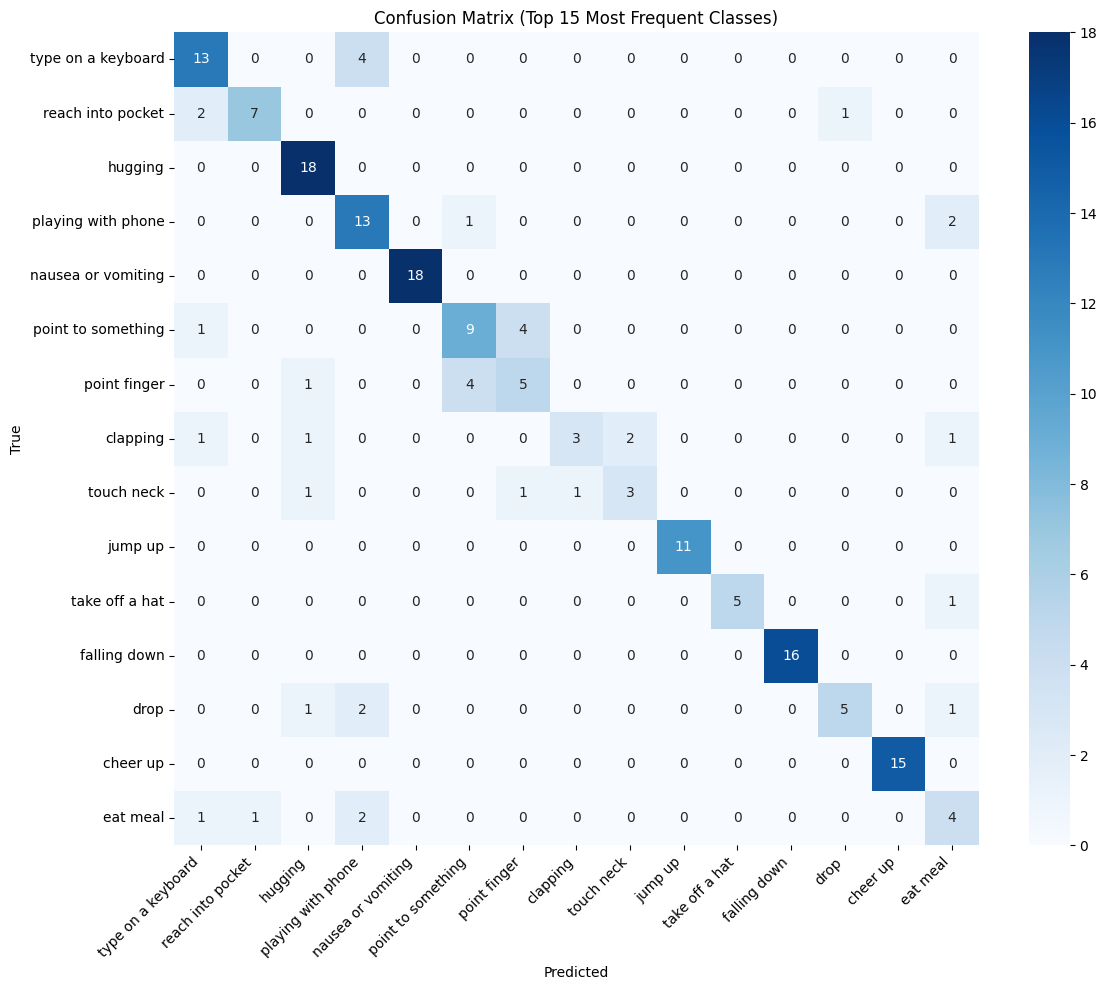

Confusion matrix includes 182 samples
Coverage: 18.2% of test samples

3. SPECIFIC ACTION TESTING

Testing specific actions: [0, 1, 9, 10, 23, 24]

Action: drink water (class 0)
Available samples: 274
  Sample 1: ✗ - Pred: brush teeth, Conf: 0.285
  Sample 2: ✗ - Pred: brush hair, Conf: 0.250
  Sample 3: ✓ - Pred: drink water, Conf: 0.238
  Sample 4: ✗ - Pred: brush hair, Conf: 0.275
  Sample 5: ✗ - Pred: brush teeth, Conf: 0.305
  Accuracy for drink water: 20.0%

Action: eat meal (class 1)
Available samples: 275
  Sample 1: ✗ - Pred: playing with phone, Conf: 0.178
  Sample 2: ✗ - Pred: type on a keyboard, Conf: 0.144
  Sample 3: ✓ - Pred: eat meal, Conf: 0.235
  Sample 4: ✗ - Pred: writing, Conf: 0.134
  Sample 5: ✗ - Pred: writing, Conf: 0.219
  Accuracy for eat meal: 20.0%

Action: clapping (class 9)
Available samples: 273
  Sample 1: ✗ - Pred: rub two hands, Conf: 0.403
  Sample 2: ✗ - Pred: type on a keyboard, Conf: 0.169
  Sample 3: ✗ - Pred: put palms together, Conf: 0.331
  Sa

In [104]:
try:
    test_model()
except Exception as e:
    print(f"Comprehensive test failed: {e}")
    print("\nFalling back to simple test...")
    simple_test()

# INFERENCE PHASE

### MediaPipe skeleton to NTU Format converter

In [33]:
import mediapipe as mp
import cv2
import numpy as np

class MediaPipeToNTUConverter:
    def __init__(self):
        self.mp_pose = mp.solutions.pose
        self.pose = self.mp_pose.Pose(
            static_image_mode=False,
            model_complexity=1,
            smooth_landmarks=True,
            enable_segmentation=False,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def create_correct_joint_mapping(self):
        """
        CORRECT mapping from MediaPipe's 33 landmarks to NTU's 25 joints
        Based on anatomical correspondence
        """
        return {
            # SPINE CHAIN (4 joints)
            0: self.calculate_pelvis,      # pelvis - calculated from hips
            1: self.calculate_middle_spine, # middle_of_spine - calculated
            20: self.calculate_spine,      # spine - calculated  
            2: self.calculate_neck,   # neck - using midpoint between shoulders (MediaPipe 11,12)
            3: 0,    # head - NOSE (0)
            
            # LEFT ARM (6 joints)
            4: 11,   # left_shoulder - LEFT_SHOULDER (11)
            5: 13,   # left_elbow - LEFT_ELBOW (13)
            6: 15,   # left_wrist - LEFT_WRIST (15)
            7: 19,   # left_hand - LEFT_PINKY (19) - closest approximation
            21: 17,  # tip_left_hand - LEFT_INDEX (17)
            22: 21,  # left_thumb - LEFT_THUMB (21)
            
            # RIGHT ARM (6 joints)
            8: 12,   # right_shoulder - RIGHT_SHOULDER (12)
            9: 14,   # right_elbow - RIGHT_ELBOW (14)
            10: 16,  # right_wrist - RIGHT_WRIST (16)
            11: 20,  # right_hand - RIGHT_PINKY (20) - closest approximation
            23: 18,  # tip_right_hand - RIGHT_INDEX (18)
            24: 22,  # right_thumb - RIGHT_THUMB (22)
            
            # LEFT LEG (4 joints)
            12: 23,  # left_hip - LEFT_HIP (23)
            13: 25,  # left_knee - LEFT_KNEE (25)
            14: 27,  # left_ankle - LEFT_ANKLE (27)
            15: 31,  # left_foot - LEFT_FOOT_INDEX (31)
            
            # RIGHT LEG (4 joints)
            16: 24,  # right_hip - RIGHT_HIP (24)
            17: 26,  # right_knee - RIGHT_KNEE (26)
            18: 28,  # right_ankle - RIGHT_ANKLE (28)
            19: 32,  # right_foot - RIGHT_FOOT_INDEX (32)
        }

    def calculate_pelvis(self, landmarks):
        """Calculate pelvis position as midpoint between hips"""
        left_hip = np.array([landmarks[23].x, landmarks[23].y, landmarks[23].z])
        right_hip = np.array([landmarks[24].x, landmarks[24].y, landmarks[24].z])
        pelvis = (left_hip + right_hip) / 2
        return pelvis

    def calculate_middle_spine(self, landmarks):
        """Calculate middle spine position"""
        left_hip = np.array([landmarks[23].x, landmarks[23].y, landmarks[23].z])
        right_hip = np.array([landmarks[24].x, landmarks[24].y, landmarks[24].z])
        left_shoulder = np.array([landmarks[11].x, landmarks[11].y, landmarks[11].z])
        right_shoulder = np.array([landmarks[12].x, landmarks[12].y, landmarks[12].z])
        
        # Midpoint between hips and shoulders
        hip_center = (left_hip + right_hip) / 2
        shoulder_center = (left_shoulder + right_shoulder) / 2
        middle_spine = (hip_center + shoulder_center) / 2
        
        return middle_spine

    def calculate_spine(self, landmarks):
        """Calculate spine position (between middle spine and neck)"""
        left_shoulder = np.array([landmarks[11].x, landmarks[11].y, landmarks[11].z])
        right_shoulder = np.array([landmarks[12].x, landmarks[12].y, landmarks[12].z])
        left_hip = np.array([landmarks[23].x, landmarks[23].y, landmarks[23].z])
        right_hip = np.array([landmarks[24].x, landmarks[24].y, landmarks[24].z])
        
        shoulder_center = (left_shoulder + right_shoulder) / 2
        hip_center = (left_hip + right_hip) / 2
        spine = shoulder_center * 0.3 + hip_center * 0.7  # Closer to hips
        
        return spine

    def calculate_neck(self, landmarks):
        """Calculate neck position as midpoint between shoulders"""
        left_shoulder = np.array([landmarks[11].x, landmarks[11].y, landmarks[11].z])
        right_shoulder = np.array([landmarks[12].x, landmarks[12].y, landmarks[12].z])
        neck = (left_shoulder + right_shoulder) / 2
        return neck

    def mediapipe_to_ntu_skeleton(self, landmarks):
        """
        Convert MediaPipe landmarks to NTU-style skeleton (25 joints, 3 coordinates)
        """
        ntu_skeleton = np.zeros((25, 3))
        
        mapping = self.create_correct_joint_mapping()

        for ntu_joint, mp_reference in mapping.items():
            if callable(mp_reference):
                # This is a calculated joint (pelvis, spine, etc.)
                ntu_skeleton[ntu_joint] = mp_reference(landmarks.landmark)
            elif mp_reference == 11:  # Special case for neck
                ntu_skeleton[ntu_joint] = self.calculate_neck(landmarks.landmark)
            elif mp_reference < len(landmarks.landmark):
                # Direct mapping
                landmark = landmarks.landmark[mp_reference]
                ntu_skeleton[ntu_joint] = [landmark.x, landmark.y, landmark.z]

        return ntu_skeleton

    def normalize_skeleton(self, skeleton):
        """
        Normalize skeleton similar to NTU preprocessing:
        - Center at pelvis
        - Scale by spine length
        """
        # Center at pelvis (joint 0)
        pelvis = skeleton[0].copy()
        centered_skeleton = skeleton - pelvis
        
        # Calculate spine length for scaling
        spine_base = centered_skeleton[0]  # pelvis
        spine_top = centered_skeleton[2]   # neck
        spine_length = np.linalg.norm(spine_top - spine_base)
        
        if spine_length > 0.1:  # Avoid division by very small numbers
            scaled_skeleton = centered_skeleton / spine_length
        else:
            scaled_skeleton = centered_skeleton
            
        return scaled_skeleton

    def process_frame(self, frame):
        """Process a frame and return normalized NTU skeleton"""
        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = self.pose.process(rgb_frame)
        
        if results.pose_landmarks:
            # Convert to NTU format
            ntu_skeleton = self.mediapipe_to_ntu_skeleton(results.pose_landmarks)
            # Normalize like NTU dataset
            normalized_skeleton = self.normalize_skeleton(ntu_skeleton)
            return normalized_skeleton
        else:
            return None

    def visualize_skeleton(self, frame, skeleton, confidence_threshold=0.5):
        """Visualize the converted NTU skeleton on frame with proper scaling"""
        h, w, _ = frame.shape
        
        # Convert normalized coordinates to pixel coordinates
        # Since the skeleton is normalized (centered at pelvis, scaled by spine length),
        # we need to scale it appropriately for the screen
        
        # Create a copy to avoid modifying the original
        display_skeleton = skeleton.copy()
        
        # Scale the skeleton to fit the screen nicely
        # We'll use the spine length as reference for scaling
        spine_length = np.linalg.norm(display_skeleton[2] - display_skeleton[0])
        
        if spine_length > 0:
            # Scale factor to make the skeleton a reasonable size on screen
            # Adjust this value to make the skeleton larger or smaller
            scale_factor = min(h, w) * 0.8 / spine_length
        else:
            scale_factor = min(h, w) * 0.4  # Default scaling
        
        # Apply scaling and center on screen
        display_skeleton *= scale_factor
        display_skeleton[:, 0] += w // 2  # Center X
        display_skeleton[:, 1] += h // 2  # Center Y
        
        # Draw joints
        for i, joint in enumerate(display_skeleton):
            x, y, _ = joint
            if 0 <= x < w and 0 <= y < h:  # Only draw if within screen bounds
                cv2.circle(frame, (int(x), int(y)), 6, (0, 255, 0), -1)
                cv2.putText(frame, str(i), (int(x), int(y-10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        
        # Draw bones (NTU bone connections)
        bone_pairs = [
            (0, 1), (1, 20), (20, 2), (2, 3),    # Spine chain
            (2, 4), (4, 5), (5, 6), (6, 7), (6, 21), (6, 22),  # Left arm
            (2, 8), (8, 9), (9, 10), (10, 11), (10, 23), (10, 24),  # Right arm
            (0, 12), (12, 13), (13, 14), (14, 15),  # Left leg
            (0, 16), (16, 17), (17, 18), (18, 19)   # Right leg
        ]
        
        for j1, j2 in bone_pairs:
            if (j1 < len(display_skeleton) and j2 < len(display_skeleton) and
                np.linalg.norm(display_skeleton[j1]) > 0 and 
                np.linalg.norm(display_skeleton[j2]) > 0):
                
                x1, y1, _ = display_skeleton[j1]
                x2, y2, _ = display_skeleton[j2]
                
                # Only draw if both points are within screen bounds
                if (0 <= x1 < w and 0 <= y1 < h and 
                    0 <= x2 < w and 0 <= y2 < h):
                    cv2.line(frame, (int(x1), int(y1)), (int(x2), int(y2)), 
                            (0, 255, 255), 3)
        
        return frame

### Test function to verify conversion

In [106]:
def test_conversion():
    """Test the MediaPipe to NTU conversion"""
    converter = MediaPipeToNTUConverter()
    
    # Test with webcam or sample image
    cap = cv2.VideoCapture(0)
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        skeleton = converter.process_frame(frame)
        
        if skeleton is not None:
            print(f"Skeleton shape: {skeleton.shape}")
            print(f"Pelvis position: {skeleton[0]}")
            print(f"Spine length: {np.linalg.norm(skeleton[2] - skeleton[0])}")
            
            # Visualize
            frame = converter.visualize_skeleton(frame, skeleton)
        
        cv2.imshow('NTU Skeleton', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

# Run test
test_conversion()

I0000 00:00:1760637981.111014   13099 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1760637981.112407  119931 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 23.2.1-1ubuntu3.1~22.04.3), renderer: AMD Radeon RX 580 2048SP (polaris10, LLVM 15.0.7, DRM 3.57, 6.8.0-85-generic)
[ WARN:0@25850.183] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@25850.183] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


### RealTime Inference

In [55]:
import time
from collections import deque
import cv2
import mediapipe as mp
import os
import pickle
import numpy as np

class RealTimePoseClassifier:
    def __init__(self, model_path='models/ntu_npy'):
        # Load trained model and artifacts
        print("Loading trained model...")
        
        try:
            # Load model files
            model_file = os.path.join(model_path, 'svm_model.pkl')
            scaler_file = os.path.join(model_path, 'feature_scaler.pkl')
            names_file = os.path.join(model_path, 'action_names.pkl')
            
            with open(model_file, 'rb') as f:
                self.svm_model = pickle.load(f)
            print("SVM model loaded")
            
            with open(scaler_file, 'rb') as f:
                self.scaler = pickle.load(f)
            print("Feature scaler loaded")
            
            with open(names_file, 'rb') as f:
                self.action_names = pickle.load(f)
            print("Action names loaded")
            
        except Exception as e:
            print(f"Error loading model: {e}")
            raise

        # Initialize converters
        print("Initializing MediaPipe converter...")
        self.converter = MediaPipeToNTUConverter()
        
        print("Initializing feature extractor...")
        self.feature_extractor = NTUProcessedFeatureExtractor()

        # Buffer for temporal features
        self.pose_buffer = deque(maxlen=30)  # Reduced for faster response
        self.prediction_buffer = deque(maxlen=10)
        self.fps_history = deque(maxlen=30)

        print(f"Model loaded successfully!")
        print(f"Action classes: {len(self.action_names)}")
        
        # Debug state
        self.last_features = None
        self.consecutive_same_predictions = 0
        self.last_prediction = None
        
        # Get expected feature length from scaler
        self.expected_feature_length = self.scaler.mean_.shape[0]
        print(f"Expected feature length: {self.expected_feature_length}")
        
        # NEW: Create a custom scaler that works with our real-time features
        self.use_custom_scaling = True
        print("Using custom feature scaling for real-time data")

    def create_simple_sequence(self):
        """
        Create a simple sequence without complex normalization
        Focus on relative movements rather than absolute positions
        """
        # Get current buffer as numpy array
        current_sequence = np.array(self.pose_buffer)  # (frames, 25, 3)
        
        if len(current_sequence) < 5:
            return None
            
        print(f"Current sequence shape: {current_sequence.shape}")
        
        # Use only recent frames for real-time responsiveness
        recent_frames = current_sequence[-20:] if len(current_sequence) > 20 else current_sequence
        
        # Create a simpler sequence format
        simple_sequence = np.zeros((300, 150))  # Still 300x150 for compatibility
        
        # Place recent frames at the end
        start_idx = 300 - len(recent_frames)
        
        for i, frame in enumerate(recent_frames):
            # Person 1 data only
            person1_data = frame.flatten()  # 75 elements
            person2_data = np.zeros(75)
            combined_data = np.concatenate([person1_data, person2_data])
            
            if len(combined_data) == 150:
                simple_sequence[start_idx + i] = combined_data
        
        return simple_sequence

    def extract_simple_features(self, ntu_skeleton):
        """
        Extract SIMPLER features that are more robust to real-time variations
        """
        # Add to pose buffer
        self.pose_buffer.append(ntu_skeleton)

        print(f"Buffer size: {len(self.pose_buffer)}")

        if len(self.pose_buffer) < 8:
            print("Not enough frames in buffer")
            return None

        try:
            # Create sequence
            sequence = self.create_simple_sequence()
            if sequence is None:
                return None
            
            print(f"Sequence shape: {sequence.shape}")
            print(f"Sequence range: [{np.min(sequence):.4f}, {np.max(sequence):.4f}]")
            
            # Extract features
            features = self.feature_extractor.extract_features_from_sequence(sequence)
            
            if features is not None and len(features) > 0:
                print(f"Raw features: {len(features)}, Range: [{np.min(features):.4f}, {np.max(features):.4f}]")
                
                # Pad features
                features_padded = self.pad_features(features)
                
                # APPLY CUSTOM NORMALIZATION instead of using the broken scaler
                features_normalized = self.custom_normalize(features_padded)
                print(f"Normalized features - Range: [{np.min(features_normalized):.4f}, {np.max(features_normalized):.4f}]")
                
                return features_normalized
            else:
                print("Feature extraction failed")
                return None
                
        except Exception as e:
            print(f"Error in feature extraction: {e}")
            return None

    def custom_normalize(self, features):
        """
        Custom normalization that works with real-time features
        This avoids the broken scaler issue
        """
        # Remove extreme outliers
        features = np.clip(features, -10, 10)
        
        # Simple standardization
        feature_mean = np.mean(features)
        feature_std = np.std(features)
        
        if feature_std > 0.001:
            normalized = (features - feature_mean) / feature_std
        else:
            normalized = features - feature_mean
        
        # Clip to reasonable range
        normalized = np.clip(normalized, -5, 5)
        
        return normalized

    def pad_features(self, features):
        """Pad features to expected length"""
        padded = np.zeros(self.expected_feature_length)
        min_len = min(len(features), self.expected_feature_length)
        padded[:min_len] = features[:min_len]
        return padded

    def predict_with_fallback(self, features):
        """
        Prediction with multiple fallback strategies
        """
        if features is None or len(features) == 0:
            return None, 0.0

        try:
            # Strategy 1: Try original scaler 
            try:
                features_scaled = self.scaler.transform([features])
                if np.max(np.abs(features_scaled)) < 100:  # Reasonable range
                    prediction = self.svm_model.predict(features_scaled)[0]
                    probabilities = self.svm_model.predict_proba(features_scaled)[0]
                    confidence = probabilities[prediction]
                    
                    print(f"Original scaler - Prediction: {self.action_names[prediction]}, Confidence: {confidence:.3f}")
                    return prediction, confidence
            except:
                print("Original scaler failed, using fallback...")

            # Strategy 2: Use custom normalized features directly
            prediction = self.svm_model.predict([features])[0]
            probabilities = self.svm_model.predict_proba([features])[0]
            confidence = probabilities[prediction]
            
            print(f"Custom normalized - Prediction: {self.action_names[prediction]}, Confidence: {confidence:.3f}")
            
            # Show top predictions
            top_3_indices = np.argsort(probabilities)[-3:][::-1]
            print("Top 3 predictions:")
            for i in top_3_indices:
                if probabilities[i] > 0.01:
                    print(f"  {self.action_names[i]:20}: {probabilities[i]:.3f}")
            
            return prediction, confidence
            
        except Exception as e:
            print(f"Prediction failed: {e}")
            return None, 0.0

    def process_single_frame(self, frame):
        """
        Process a single frame and return prediction
        """
        try:
            # Process frame with MediaPipe
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.converter.pose.process(rgb_frame)

            if results.pose_landmarks:
                # Convert to NTU format
                ntu_skeleton = self.converter.mediapipe_to_ntu_skeleton(results.pose_landmarks)
                
                if np.any(ntu_skeleton != 0):
                    return ntu_skeleton, results.pose_landmarks
                    
            return None, None
                
        except Exception as e:
            print(f"Error processing frame: {e}")
            return None, None

    def smooth_prediction(self, current_pred, current_confidence):
        """Simple smoothing"""
        if current_pred is None:
            return None, 0.0

        self.prediction_buffer.append((current_pred, current_confidence))

        if len(self.prediction_buffer) < 2:
            return current_pred, current_confidence

        # Return the most recent prediction for faster response
        return current_pred, current_confidence

    def draw_skeleton(self, image, landmarks):
        """Draw MediaPipe skeleton"""
        mp.solutions.drawing_utils.draw_landmarks(
            image,
            landmarks,
            mp.solutions.pose.POSE_CONNECTIONS,
            mp.solutions.drawing_styles.get_default_pose_landmarks_style()
        )

    def draw_prediction(self, image, prediction, confidence, fps):
        """Draw prediction and info"""
        if prediction is not None:
            action_name = self.action_names[prediction]
            
            color = (0, 255, 0) if confidence > 0.6 else (0, 255, 255)
            
            cv2.rectangle(image, (10, 10), (500, 90), (0, 0, 0), -1)
            cv2.rectangle(image, (10, 10), (500, 90), color, 2)

            cv2.putText(image, f"Action: {action_name}", (20, 35),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
            cv2.putText(image, f"Confidence: {confidence:.2f}", (20, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            cv2.putText(image, f"FPS: {fps:.1f}", (20, 85),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        else:
            cv2.putText(image, "No pose detected", (20, 40),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    def run_realtime_demo(self):
        """Main real-time loop"""
        print("Initializing webcam...")
        
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            print("Cannot access webcam")
            return

        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
        cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
        
        print("Starting real-time pose classification...")
        print("Press 'q' to quit, 'r' to reset")
        print("The system will use fallback strategies to avoid stuck predictions")

        last_time = time.time()
        frame_count = 0
        last_prediction_time = 0
        prediction_interval = 0.4

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            current_time = time.time()

            # Calculate FPS
            frame_count += 1
            if current_time - last_time >= 1.0:
                fps = frame_count / (current_time - last_time)
                self.fps_history.append(fps)
                frame_count = 0
                last_time = current_time
            avg_fps = np.mean(self.fps_history) if self.fps_history else 0

            try:
                # Process frame
                ntu_skeleton, landmarks = self.process_single_frame(frame)

                if ntu_skeleton is not None and landmarks is not None:
                    self.draw_skeleton(frame, landmarks)

                    # Predict at intervals
                    if current_time - last_prediction_time >= prediction_interval:
                        features = self.extract_simple_features(ntu_skeleton)
                        
                        if features is not None:
                            
                            current_pred, current_conf = self.predict_with_fallback(features)
                            
                            final_pred, final_conf = self.smooth_prediction(current_pred, current_conf)
                            last_prediction_time = current_time
                            
                            if final_pred is not None:
                                action_name = self.action_names[final_pred]
                                print(f"=== FINAL: {action_name} (confidence: {final_conf:.2f}) ===")
                                
                                # Track consecutive predictions
                                if self.last_prediction == final_pred:
                                    self.consecutive_same_predictions += 1
                                else:
                                    self.consecutive_same_predictions = 0
                                self.last_prediction = final_pred
                        else:
                            final_pred, final_conf = None, 0.0
                else:
                    final_pred, final_conf = None, 0.0
                    if len(self.pose_buffer) > 5:
                        self.pose_buffer.clear()

                self.draw_prediction(frame, final_pred, final_conf, avg_fps)

            except Exception as e:
                print(f"Error: {e}")
                final_pred, final_conf = None, 0.0

            cv2.imshow('Real-time Pose Classification', frame)

            key = cv2.waitKey(1) & 0xFF
            if key == ord('q'):
                break
            elif key == ord('r'):
                self.pose_buffer.clear()
                self.prediction_buffer.clear()
                self.last_features = None
                self.consecutive_same_predictions = 0
                self.last_prediction = None
                print("=== RESET ===")

        cap.release()
        cv2.destroyAllWindows()
        print("Real-time demo ended")

def test_realtime_classifier():
    try:
        classifier = RealTimePoseClassifier()
        print("RealTimePoseClassifier initialized successfully!")
        return classifier
    except Exception as e:
        print(f"Error: {e}")
        return None



In [56]:
classifier = test_realtime_classifier()

Loading trained model...
SVM model loaded
Feature scaler loaded
Action names loaded
Initializing MediaPipe converter...
Initializing feature extractor...
Model loaded successfully!
Action classes: 60
Expected feature length: 662
Using custom feature scaling for real-time data
RealTimePoseClassifier initialized successfully!


c:\Users\khaye\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\khaye\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [57]:
if classifier:
    classifier.run_realtime_demo()

Initializing webcam...
Starting real-time pose classification...
Press 'q' to quit, 'r' to reset
The system will use fallback strategies to avoid stuck predictions
Buffer size: 1
Not enough frames in buffer
Buffer size: 2
Not enough frames in buffer
Buffer size: 3
Not enough frames in buffer
Buffer size: 4
Not enough frames in buffer
Buffer size: 5
Not enough frames in buffer
Buffer size: 6
Not enough frames in buffer
Buffer size: 7
Not enough frames in buffer
Buffer size: 8
Current sequence shape: (8, 25, 3)
Sequence shape: (300, 150)
Sequence range: [-1.6160, 2.6760]
Raw features: 662, Range: [-1.2678, 4.9423]
Normalized features - Range: [-2.2370, 5.0000]
Custom normalized - Prediction: hand waving, Confidence: 0.159
Top 3 predictions:
  hand waving         : 0.159
  taking a selfie     : 0.151
  point to something  : 0.116
=== FINAL: hand waving (confidence: 0.16) ===
Buffer size: 9
Current sequence shape: (9, 25, 3)
Sequence shape: (300, 150)
Sequence range: [-1.6160, 2.6760]
Raw 